In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

from rdkit import Chem
from rdkit.Chem import Descriptors, Draw, AllChem, DataStructs, Crippen, Lipinski
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

np.random.seed(0)

## 1. Load real bioactivity data — the BACE-1 dataset

**BACE-1** (β-secretase 1) is an enzyme implicated in Alzheimer's disease. This dataset is the canonical single-target QSAR benchmark: ~1,500 small molecules, each with a measured **pIC50** against BACE-1, curated from the literature by MoleculeNet.

- `smiles` — the molecule, as a text string.
- `pIC50` — our regression label. Higher = more potent 

This is exactly the shape of a real lead-optimization dataset: one target, hundreds of molecules clustered into chemical *series*.

In [2]:
URL = "https://raw.githubusercontent.com/illidanlab/MoCL-DK/master/dataset/bace/raw/bace.csv"
df = pd.read_csv(URL)[["mol", "pIC50"]].rename(columns={"mol": "smiles"})

In [3]:
df.head(2)

,smiles,pIC50
0,O1CC[C@@H](NC(=O)[C@@H](Cc2cc3cc(ccc3nc2N)-c2c...,9.154901
1,Fc1cc(cc(F)c1)C[C@H](NC(=O)[C@@H](N1CC[C@](NC(...,8.853872


In [ ]:
# Convert SMILES to RDKit Mol objects - remove everything that can't be parsed
df["rdmol"] = df["smiles"].apply(Chem.MolFromSmiles)

In [7]:
print(df.shape)
print(f"Number of non-null values in df['rdmol']: {df['rdmol'].notna().sum()}")
print(f"\n{len(df)} compounds | pIC50 range "
      f"{df.pIC50.min():.2f}–{df.pIC50.max():.2f}, mean {df.pIC50.mean():.2f}")

(1513, 3)
Number of non-null values in df['rdmol']: 1513

1513 compounds | pIC50 range 2.54–10.52, mean 6.52


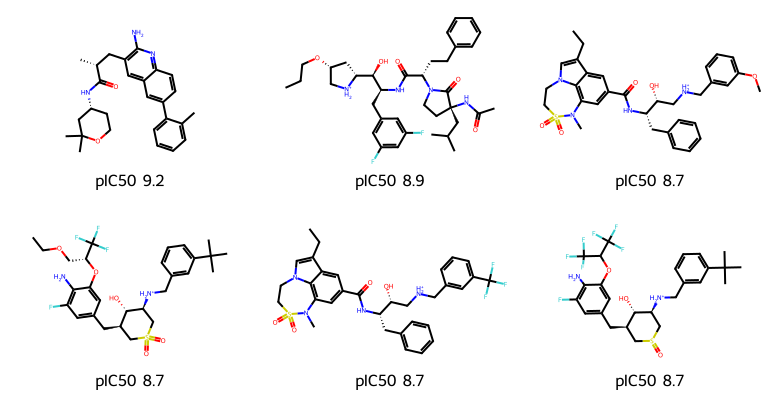

In [8]:
mols = df["rdmol"].iloc[:6].tolist()
legends = [f"pIC50 {v:.1f}" for v in df["pIC50"].iloc[:6]]
Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(260, 200), legends=legends)

## Lipinski

A molecule that binds is useless if it can't behave like a drug. RDKit computes the **Lipinski Rule-of-Five** properties in one line each. Recall the rough thresholds for oral druglikeness:

| Property | Rule-of-Five limit |
|---|---|
| Molecular weight | ≤ 500 |
| LogP (lipophilicity) | ≤ 5 |
| H-bond donors | ≤ 5 |
| H-bond acceptors | ≤ 10 |

These are *guidelines*, not laws — but a model that proposes molecules wildly outside them is proposing things no chemist will make.

In [9]:
df.head(2)

,smiles,pIC50,rdmol
0,O1CC[C@@H](NC(=O)[C@@H](Cc2cc3cc(ccc3nc2N)-c2c...,9.154901,<rdkit.Chem.rdchem.Mol object at 0x120ec5cb0>
1,Fc1cc(cc(F)c1)C[C@H](NC(=O)[C@@H](N1CC[C@](NC(...,8.853872,<rdkit.Chem.rdchem.Mol object at 0x120ec5d90>


In [10]:
def lipinski_row(rdmol_obj):
    return pd.Series({
        "MW":   Descriptors.MolWt(rdmol_obj),
        "LogP": Crippen.MolLogP(rdmol_obj),
        "HBD":  Lipinski.NumHDonors(rdmol_obj),
        "HBA":  Lipinski.NumHAcceptors(rdmol_obj),
    })

lipinski_props = df["rdmol"].apply(lipinski_row)
df = pd.concat([df, lipinski_props], axis=1)
df.head(2)

,smiles,pIC50,rdmol,MW,LogP,HBD,HBA
0,O1CC[C@@H](NC(=O)[C@@H](Cc2cc3cc(ccc3nc2N)-c2c...,9.154901,<rdkit.Chem.rdchem.Mol object at 0x120ec5cb0>,431.580,5.04482,2.0,4.0
1,Fc1cc(cc(F)c1)C[C@H](NC(=O)[C@@H](N1CC[C@](NC(...,8.853872,<rdkit.Chem.rdchem.Mol object at 0x120ec5d90>,657.823,2.63860,4.0,5.0


In [11]:
# Check how many compounds conform to Lipinski's rule of 5
is_lipinski = ((df["MW"] <= 500) & (df["LogP"] <= 5) & (df["HBD"] <= 5) & (df["HBA"] <= 10))
print(f"{is_lipinski.sum()} of {len(df)} compounds ({100 * is_lipinski.mean():.1f}%) conform to Lipinski's rule of 5")

860 of 1513 compounds (56.8%) conform to Lipinski's rule of 5


## IC50 ↔ pIC50 by hand — making the label concrete

Label **pIC50** is defined as:

$$\text{pIC50} = -\log_{10}(\text{IC50 in molar})$$

Why train on this instead of raw IC50?
- IC50 spans many orders of magnitude (nanomolar to millimolar) → the log makes it well-distributed for regression.
- The minus sign flips direction so **higher pIC50 = more potent** (intuitive).

Let's back-convert a few pIC50 values into IC50 in nanomolar so the number means something physical. (IC50[M] = 10^(−pIC50); in nM, multiply by 1e9, i.e. IC50[nM] = 10^(9 − pIC50).)

In [23]:
def pic50_to_ic50_nM(pic50):
    '''
    Convert pic50 value to IC50 in nM.
    '''
    return 10 ** (9 - pic50)

for v in [4.0, 6.0, 7.0, 9.0]:
    print(f"pIC50 {v:.1f} -> IC50 {pic50_to_ic50_nM(v):>10,.1f} nM")

print("\nNote: each +1 in pIC50 = 10x tighter binding. "
      "pIC50 9 (≈1 nM) is a drug; pIC50 4 (≈100,000 nM) is barely active.")

# And the forward direction you'd run on raw assay data:
def ic50_nM_to_pic50(ic50_nM):
    return 9 - np.log10(ic50_nM)
print(f"\nRound-trip check: 100 nM -> pIC50 {ic50_nM_to_pic50(100):.2f} -> "
      f"{pic50_to_ic50_nM(ic50_nM_to_pic50(100)):.0f} nM")

pIC50 4.0 -> IC50  100,000.0 nM
pIC50 6.0 -> IC50    1,000.0 nM
pIC50 7.0 -> IC50      100.0 nM
pIC50 9.0 -> IC50        1.0 nM

Note: each +1 in pIC50 = 10x tighter binding. pIC50 9 (≈1 nM) is a drug; pIC50 4 (≈100,000 nM) is barely active.

Round-trip check: 100 nM -> pIC50 7.00 -> 100 nM


> **Trap to remember:** IC50 is *assay-dependent*. Pooling IC50 values measured under different conditions into one training target injects label noise you cannot model away. Real curation means filtering to comparable assays *before* converting to pIC50.

### Featurization: molecules → vectors (Morgan fingerprints)

A Random Forest can't read a graph. The classic QSAR move is the **Morgan / ECFP fingerprint**: a fixed-length bit vector where each bit marks the presence of a local substructure. Here, 2048 bits, radius 2.

In [25]:
def morgan_fingerprint(m, n_bits=2048, radius=2):
    # Calculate Morgan fingerprint as a bit vector
    bv = AllChem.GetMorganFingerprintAsBitVect(m, radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=np.int8)
    # Convert the bit vector to a numpy array
    DataStructs.ConvertToNumpyArray(bv, arr)
    return arr

X = np.vstack(df["rdmol"].apply(morgan_fingerprint).values)
y = df["pIC50"].values
print(f"Feature matrix X: {X.shape}  ({X.shape[0]} compounds x {X.shape[1]} bits)")
print(f"Labels y:        {y.shape}")

Feature matrix X: (1513, 2048)  (1513 compounds x 2048 bits)
Labels y:        (1513,)


## Bemis–Murcko scaffolds — the source of leakage

Chemists optimize molecules in **series**: they pick a promising core ("scaffold") and decorate it dozens of ways. So a bioactivity dataset is full of near-duplicates that share a scaffold.

The **Bemis–Murcko scaffold** strips a molecule down to its ring systems + linkers, giving the shared core. Let's compute it and see how concentrated the data is.

In [26]:
# Define a function to extract the scaffold from a molecule
def scaffold_of(m):
    # Extract the Murcko scaffold from a molecule and return it as a SMILES string
    return MurckoScaffold.MurckoScaffoldSmiles(mol=m, includeChirality=False)

df["scaffold"] = df["rdmol"].apply(scaffold_of)
n_scaf = df["scaffold"].nunique()
print(f"{len(df)} molecules collapse into just {n_scaf} distinct scaffolds.")

top = df["scaffold"].value_counts().head(5)
print("\nMost common scaffolds (these are tight molecular series):")
for scaf, cnt in top.items():
    print(f"  {cnt:3d} molecules share scaffold:  {scaf[:60]}")

1513 molecules collapse into just 671 distinct scaffolds.

Most common scaffolds (these are tight molecular series):
   55 molecules share scaffold:  O=C1NC=NC1(c1ccccc1)c1ccccc1
   53 molecules share scaffold:  O=S1(=O)CC(Cc2ccccc2)CC([NH2+]Cc2ccccc2)C1
   41 molecules share scaffold:  c1ccc(CCCC[NH2+]C2(c3ccccc3)CCCCC2)cc1
   31 molecules share scaffold:  c1ccc(CCCC[NH2+]C2CC3(CCC3)Oc3ncccc32)cc1
   26 molecules share scaffold:  O=C(NC(CC[NH2+]Cc1ccccc1)Cc1ccccc1)c1ccccc1


This is the whole problem in one statistic: a few hundred scaffolds account for over a thousand molecules. A **random** split scatters members of the same series across train and test — so the model gets tested on molecules nearly identical to ones it trained on. That's not generalization; it's a lookup.

## EXPERIMENT — random split vs. scaffold split

Same features, same model, same test-set *size*. The only thing changed is **how** we split.

In [ ]:
def train_and_eval(train_idx, test_idx, label):
    model = RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=0)
    model.fit(X[train_idx], y[train_idx])
    pred = model.predict(X[test_idx])
    r2   = r2_score(y[test_idx], pred)
    rmse = np.sqrt(mean_squared_error(y[test_idx], pred))
    print(f"{label:16s}  n_test={len(test_idx):4d}   R2={r2:5.3f}   RMSE={rmse:.3f}")
    return dict(label=label, y_true=y[test_idx], y_pred=pred, r2=r2, rmse=rmse)

# --- (a) RANDOM split: shuffle rows, take last 20% as test ---
rng = np.random.RandomState(42)
perm = rng.permutation(len(df))
cut = int(0.8 * len(df))
res_random = train_and_eval(perm[:cut], perm[cut:], "RANDOM split")

# --- (b) SCAFFOLD split: whole scaffolds go to ONE side only ---
# Fill train with largest scaffolds first until ~80%; the rest (unseen cores) become test.
groups = defaultdict(list)
for i, s in enumerate(df["scaffold"]):
    groups[s].append(i)
ordered = sorted(groups.values(), key=len, reverse=True)

train_idx, test_idx = [], []
for g in ordered:
    if len(train_idx) + len(g) <= 0.8 * len(df):
        train_idx += g
    else:
        test_idx += g
res_scaffold = train_and_eval(np.array(train_idx), np.array(test_idx), "SCAFFOLD split")

drop = res_random["r2"] - res_scaffold["r2"]
print(f"\n>>> R2 dropped by {drop:.2f} ({drop/res_random['r2']*100:.0f}%) "
      f"just by splitting honestly. The random number was measuring memorization.")